In [1]:
from __future__ import annotations

from dataclasses import dataclass

import petsc4py.PETSc as PETSc
import numpy as np
from ufl import det, tr
from dolfinx import fem
import ufl

from homicsx import(
    Inclusion,
    RVEGeometry, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    NonlinearMaterialModel,
    ProblemSettings,
)
from homicsx.mesh import generate_mesh
from homicsx.fem import build_nonlinear_periodic_fluctuation_peoblem
from homicsx.homogenization import plot_homogenization_summary, plot_each_load_case
from homicsx.visualization import visualize_geometry

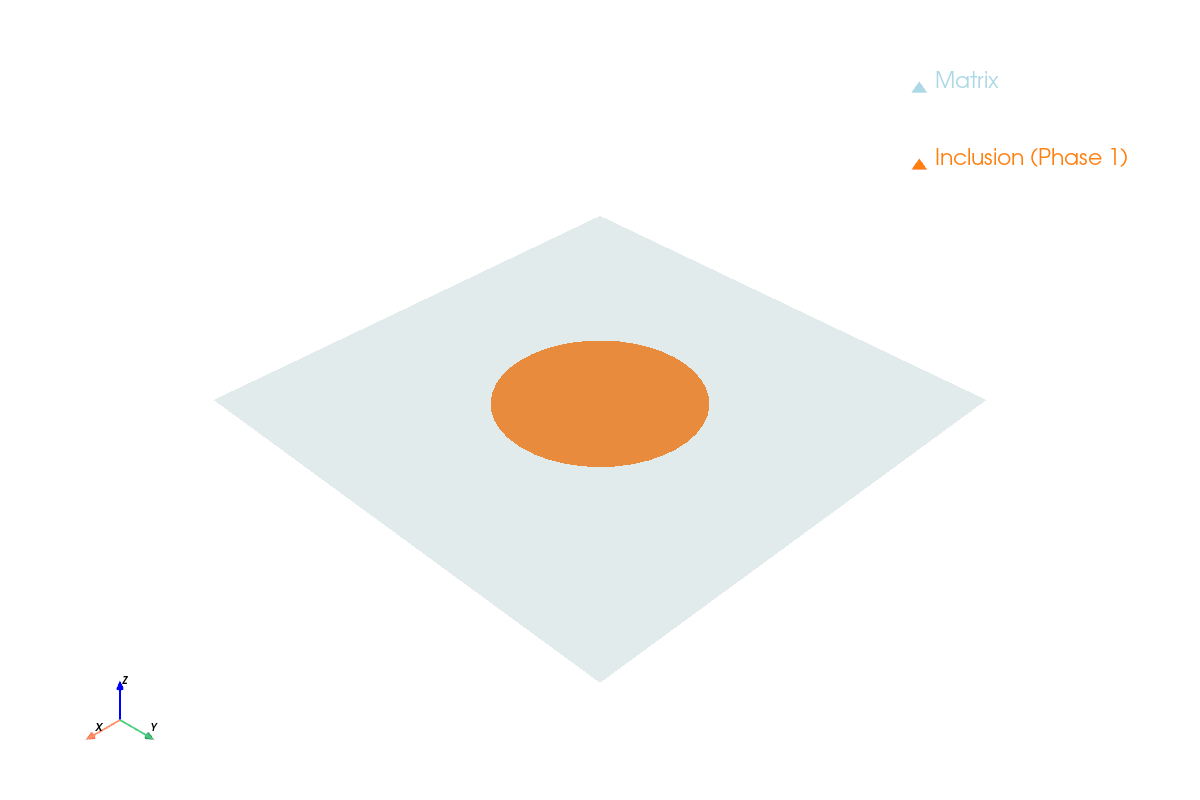

In [2]:
dim = 2
domain_size = (1, 1)

inclusion = Inclusion(
    center=[0.5, 0.5],
    phase_id=1,
    shape='circle',
    radii=0.2,
)

geometry = RVEGeometry(
    dim=dim,
    domain_size=domain_size,
    inclusions=[inclusion],
)

visualize_geometry(geometry)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.02,
    max_size=0.04,
    physical_tags=physical_tags,
    quad_hex=True,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

In [3]:
@dataclass
class NeoHookeanDecoupled(NonlinearMaterialModel):
    def __init__(self, kappa, mu):
        self.kappa = kappa
        self.mu = mu
    
    def psi_form(self, F):
        dim = F.ufl_shape[0]
        C = F.T * F
        J = det(F)
        I1 = J**(-2/3) * (tr(C) + 1)
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)

kappa_mat = 17.5
mu_mat = 8.0
mat_matrix = NeoHookeanDecoupled(kappa=kappa_mat, mu=mu_mat)

kappa_inc = 100 * kappa_mat
mu_inc = 100 * mu_mat
mat_inclusion = NeoHookeanDecoupled(kappa=kappa_inc, mu=mu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_inclusion,
    }
)

In [4]:
fem_settings = ProblemSettings(
    dim = dim,
    kinematics='finite_strain',
    two_dimensional_formulation='plane_strain',
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-8,
        "snes_atol": 1e-10,
        "snes_max_it": 10,
    }
)

In [5]:
def make_Fbar(a: float):
    """Make Fbar for uniaxial tension in x direction."""
    Fbar = np.eye(dim, dtype=PETSc.ScalarType)
    Fbar[0, 0] = 1 + a
    return Fbar

from homicsx.homogenization.nlhelpers import (
    solve_once, 
    compute_average_P_and_energy, 
    compute_Ceff_fd, 
    init_history,
    record_history,
    summarize_histories,
)

In [6]:
max_load = 0.4
num_steps = 11
load_steps = np.linspace(0, max_load, num_steps)
perturbation_delta = 1e-6
load_name = 'tension_x'

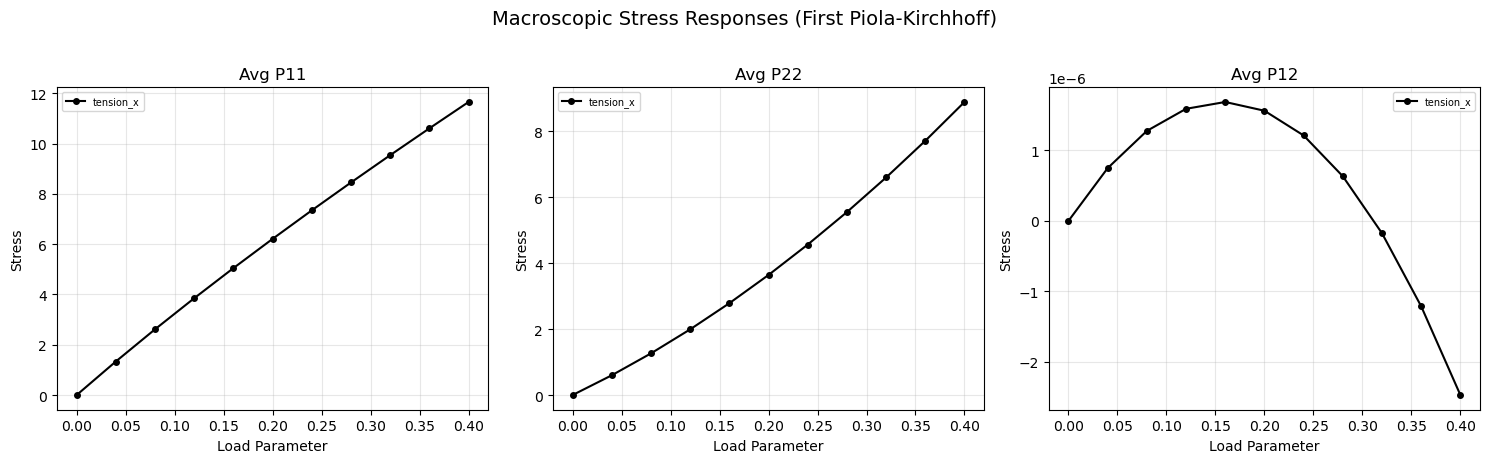

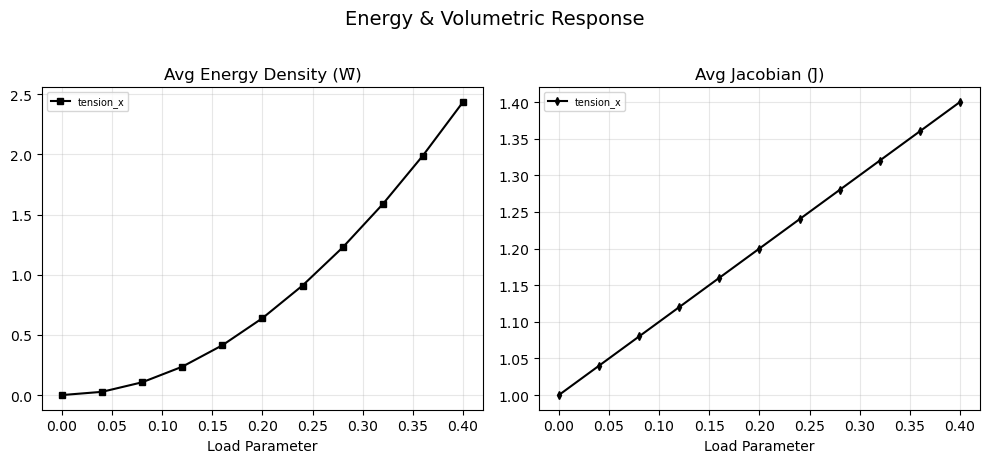

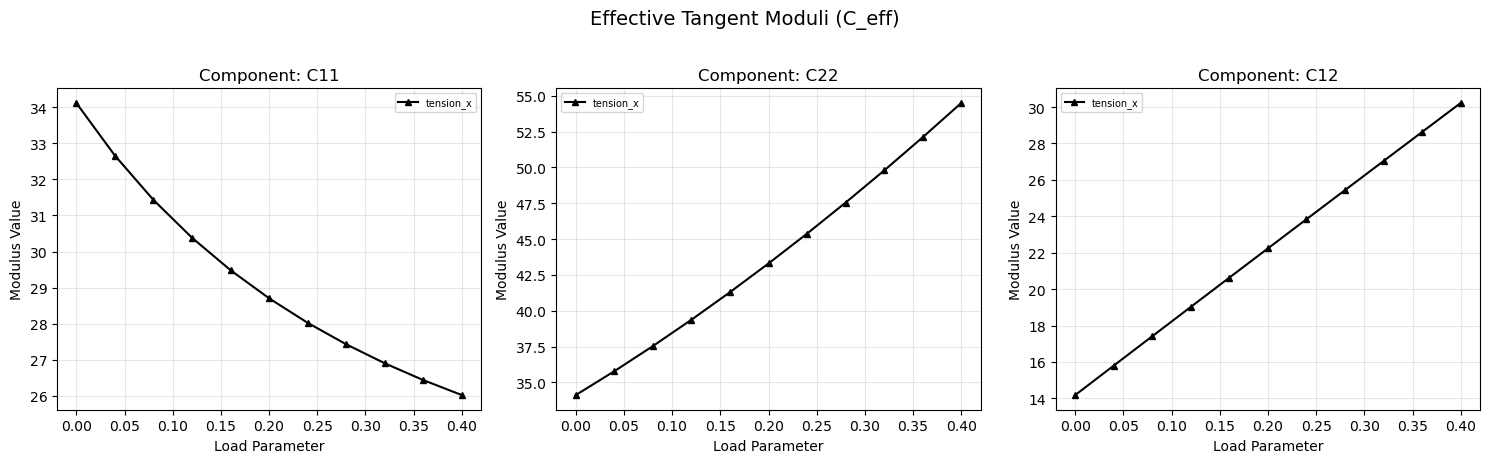

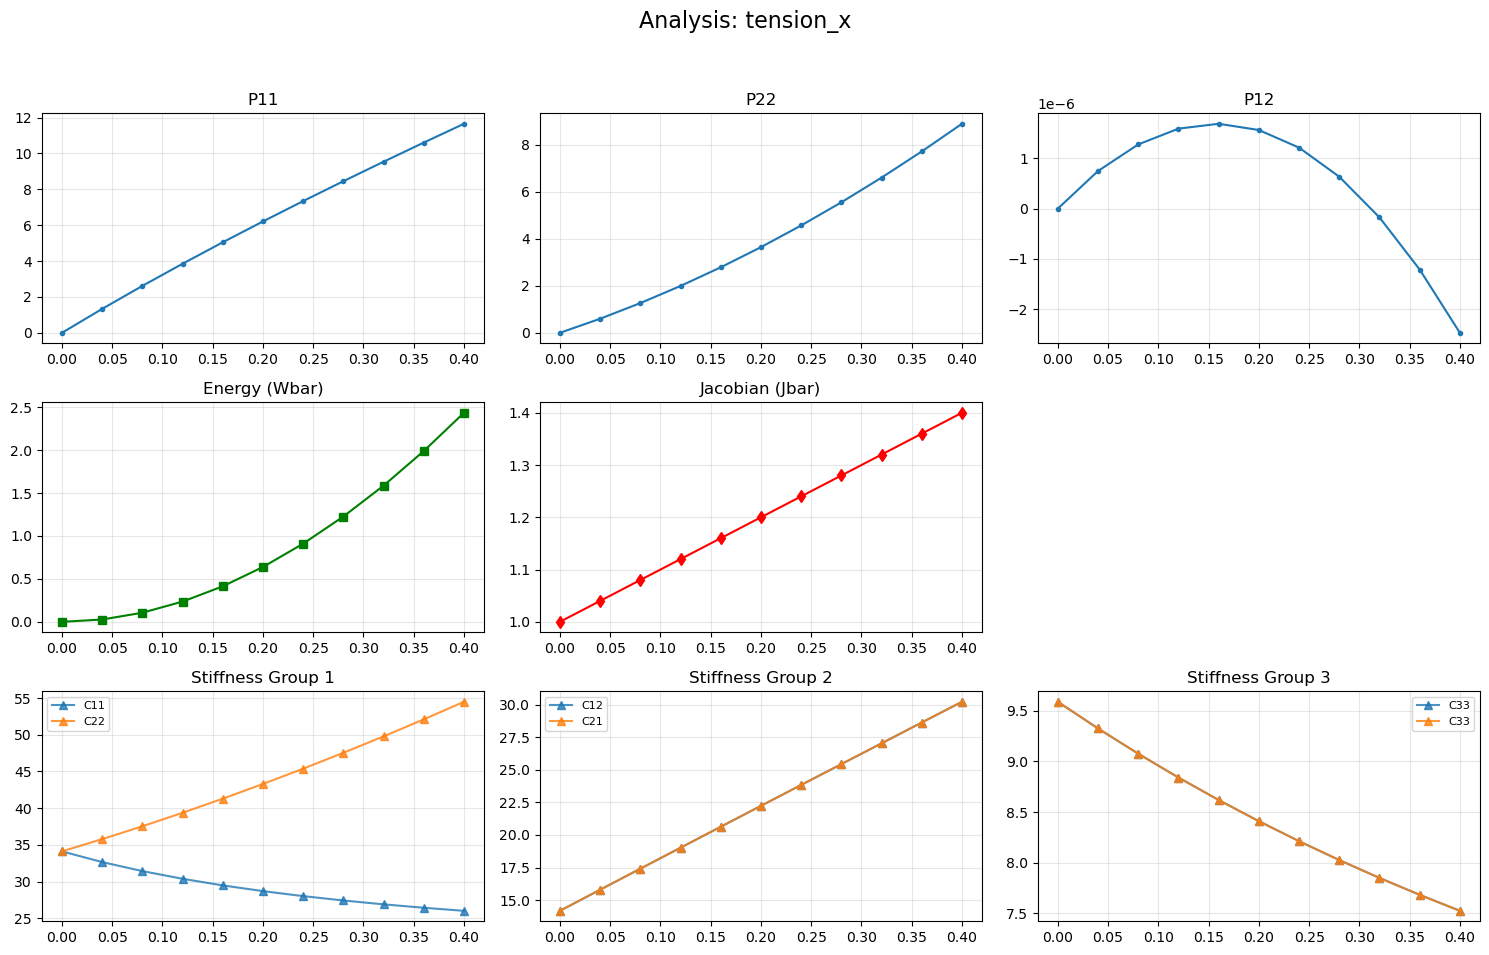

{'tension_x': {'load': array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ]), 'P11': array([ 0.        ,  1.33477076,  2.61595068,  3.85170366,  5.04859682,
        6.21197584,  7.34623866,  8.45503849,  9.54143634, 10.60801743,
       11.65698095]), 'P22': array([0.        , 0.5995376 , 1.26373496, 1.99245635, 2.78556986,
       3.64295046, 4.56448149, 5.5500555 , 6.59957427, 7.71294863,
       8.89009781]), 'Wbar': array([0.        , 0.0268897 , 0.10606805, 0.23556077, 0.41368675,
       0.63900207, 0.91025693, 1.22636192, 1.58636152, 1.98941278,
       2.43476815]), 'Jbar': array([1.  , 1.04, 1.08, 1.12, 1.16, 1.2 , 1.24, 1.28, 1.32, 1.36, 1.4 ]), 'P12': array([ 0.00000000e+00,  7.48609064e-07,  1.27716863e-06,  1.59073502e-06,
        1.68755902e-06,  1.56338938e-06,  1.21270105e-06,  6.33375249e-07,
       -1.75581210e-07, -1.21265955e-06, -2.47163413e-06]), 'P21': array([ 0.00000000e+00,  7.19817397e-07,  1.18256354e-06,  1.42029911e-06,
        1.45479047e-06

In [7]:
problem, context = build_nonlinear_periodic_fluctuation_peoblem(
    mesh_obj=domain,
        cell_tags=ct,
        facet_tags=ft,
        assignment=material_assignment,
        settings=fem_settings,
        physical_tags=physical_tags,
        domain_size=domain_size,
        matrix_phase_id=0,
        petsc_options=fem_settings.petsc_options,
)

u = context.fluctuation_field
F_macro = context.F_macro

u_prev = fem.Function(u.function_space)
u_prev.x.array[:] = u.x.array[:]

dx = ufl.Measure("dx", domain=domain, subdomain_data=ct)

history_dict = {}
history = init_history()

for step_idx, load in enumerate(load_steps):
    Fbar = make_Fbar(load)

    u.x.array[:] = u_prev.x.array[:] 
    u.x.scatter_forward()

    u, converged, iters = solve_once(problem, u, F_macro, Fbar)
    u_prev.x.array[:] = u.x.array[:]

    Pbar, Wbar, Jbar = compute_average_P_and_energy(domain, u, F_macro, material_assignment, ct, dim)

    Ceff = compute_Ceff_fd(problem, u, F_macro, domain, material_assignment, ct, Fbar, dim, perturbation_delta)

    record_history(history, step_idx, load, load_name, Fbar, Pbar, Wbar, Jbar, converged, iters, Ceff)

    u.x.array[:] = u_prev.x.array[:]
    u.x.scatter_forward()

history_dict[load_name] = history
summary = summarize_histories(history_dict, dim)

plot_homogenization_summary(summary, dim=dim, save=False)
plot_each_load_case(summary, dim=dim, save=False)

print(summary)   